# 02 — Марковская модель рисков

## Цель

Калибровать марковскую цепь для переходов клиентов между состояниями риска и получить риск-параметры каждого клиента для оптимизатора:

$$EV_i = 40 - PD_i \times LGD_i \times EAD_i$$

| Вход | Источник |
|------|----------|
| `df_features.csv` | Ноутбук 01 (EDA) |
| Матрица переходов **T** | Калибруется ниже |

| Выход | Используется в |
|-------|----------------|
| `df_risk.csv` | Ноутбуки 03–05 |

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

ROOT = Path().cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

from markov_risk import (
    DEFAULT_T, STATES, TIER_COLORS,
    TRANSITION_MATRICES, SCENARIO_REFERENCES, get_transition_matrix,
    LADDER_STATES, get_ladder_matrix, project_ladder, ladder_annual_pd,
    validate, annual_pd, stationary, project,
    assign_params, sensitivity,
    plot_transition, plot_annual_pd, plot_projection,
    plot_ev_distribution, plot_sensitivity,
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

df = pd.read_csv(ROOT / 'data' / 'df_features.csv')
print(f'Загружено {len(df):,} строк  |  Столбцов: {len(df.columns)}')
print(f'Уровни риска: {df["risk_label"].value_counts().to_dict()}')

Загружено 30,000 строк  |  Столбцов: 13
Уровни риска: {'Near-Prime': 15103, 'Prime': 7520, 'Sub-Prime': 7377}


---
## 1. Матрица переходов

Четыре состояния: **Prime** (otp ≥ 95%), **Near-Prime** (85–95%), **Sub-Prime** (80–85%), **Default** (поглощающее).

Месячные вероятности переходов — калиброваны для необеспеченного потребительского микрокредитования:

| Из → Default | Месячная PD | Обоснование |
|--------------|-------------|-------------|
| Prime | 0.5% | Низкий риск, стабильная история погашений |
| Near-Prime | 1.5% | Умеренный риск, периодические задержки |
| Sub-Prime | 5.0% | Высокий риск, частые просрочки |

Также моделируются повышения (Near-Prime → Prime, 4%/мес.) и понижения.

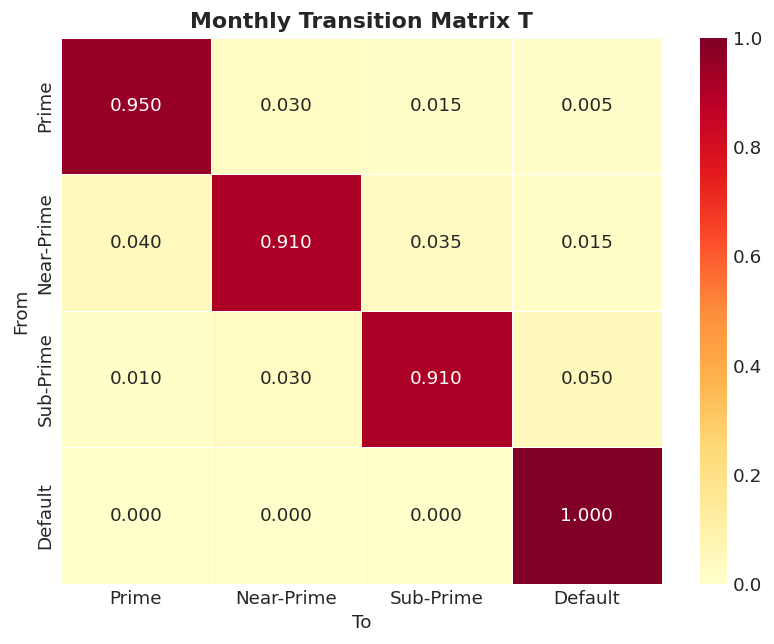

Сценарий матрицы: base
Референсы:
 - FRED DRCCLACBS (Delinquency Rate on Credit Card Loans)
 - FRED CORCCACBS (Charge-Off Rate on Credit Card Loans)

Месячная PD по уровням:
  Prime       : 0.5%
  Near-Prime  : 1.5%
  Sub-Prime   : 5.0%


In [2]:
scenario = 'base'
T = get_transition_matrix(scenario)
validate(T)
plot_transition(T)

print(f'Сценарий матрицы: {scenario}')
print('Референсы:')
print(' -', SCENARIO_REFERENCES['source_1'])
print(' -', SCENARIO_REFERENCES['source_2'])

print('\nМесячная PD по уровням:')
for i, s in enumerate(STATES[:3]):
    print(f'  {s:<12}: {T[i, 3]:.1%}')

### 1.1 Альтернативные калибровки (soft / base / conservative)

Используем 2 публичных бенчмарка как reference baseline:
- `FRED DRCCLACBS` — Delinquency Rate on Credit Card Loans
- `FRED CORCCACBS` — Charge-Off Rate on Credit Card Loans

На их основе задаем 3 сценария месячной PD (в [src/markov_risk.py](src/markov_risk.py)):
- `soft`: более мягкая кредитная среда
- `base`: базовая калибровка
- `conservative`: стрессовая/консервативная среда

Важно: это benchmark-anchored калибровки, а не прямые one-to-one оценки из нашего датасета.

In [3]:
rows = []
for name in ['soft', 'base', 'conservative']:
    T_s = get_transition_matrix(name)
    p = annual_pd(T_s)
    tmp = assign_params(df, T_s, lgd=0.55, ead_pct=0.50, profit=40)
    rows.append({
        'scenario': name,
        'pd_m_prime': T_s[0, 3],
        'pd_m_near': T_s[1, 3],
        'pd_m_sub': T_s[2, 3],
        'pd_a_prime': p[0],
        'pd_a_near': p[1],
        'pd_a_sub': p[2],
        'ev_pos_pct': (tmp['ev_per_increase'] > 0).mean(),
        'avg_ev': tmp['ev_per_increase'].mean(),
    })

scn = pd.DataFrame(rows)
for c in [c for c in scn.columns if c.startswith('pd_') or c.endswith('_pct')]:
    scn[c] = scn[c] * 100

display(scn.round(2))

,scenario,pd_m_prime,pd_m_near,pd_m_sub,pd_a_prime,pd_a_near,pd_a_sub,ev_pos_pct,avg_ev
0,soft,0.35,1.2,4.0,8.15,15.89,33.88,92.42,27.31
1,base,0.50,1.5,5.0,10.56,19.49,40.43,88.46,24.02
2,conservative,0.75,2.2,7.0,14.83,26.73,51.74,83.84,17.15


### 1.2 Лестница просрочки (Current -> ... -> ChargeOff)

Ниже визуализируем 6-state матрицы переходов для каждого tier в `base`-сценарии:

- `Current`
- `DPD_1_29`
- `DPD_30_59`
- `DPD_60_89`
- `DPD_90_plus`
- `ChargeOff`

Также строим 12-месячную траекторию долей состояний при старте из `Current`.

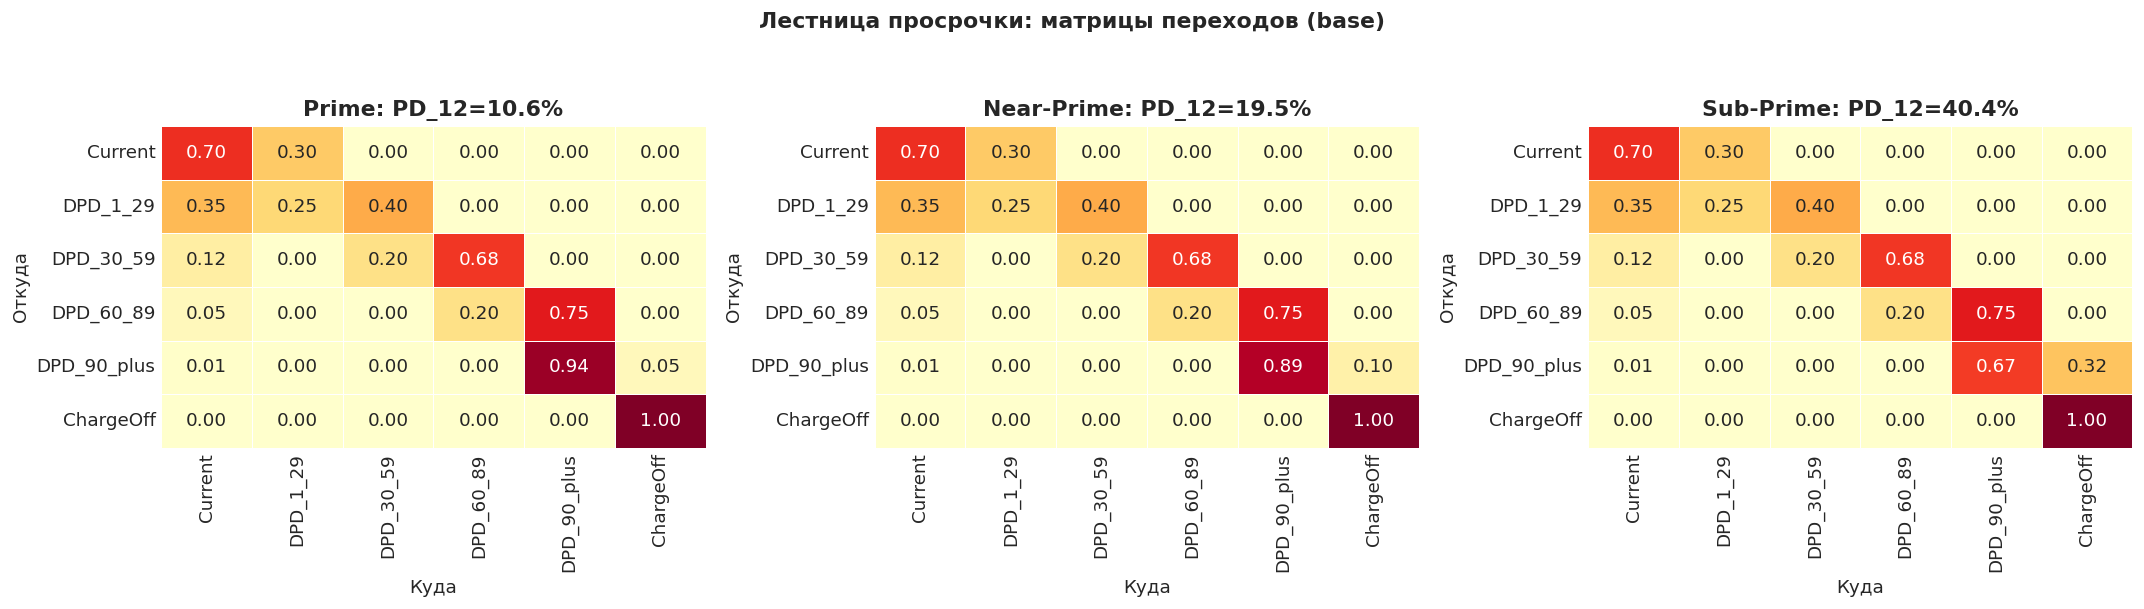

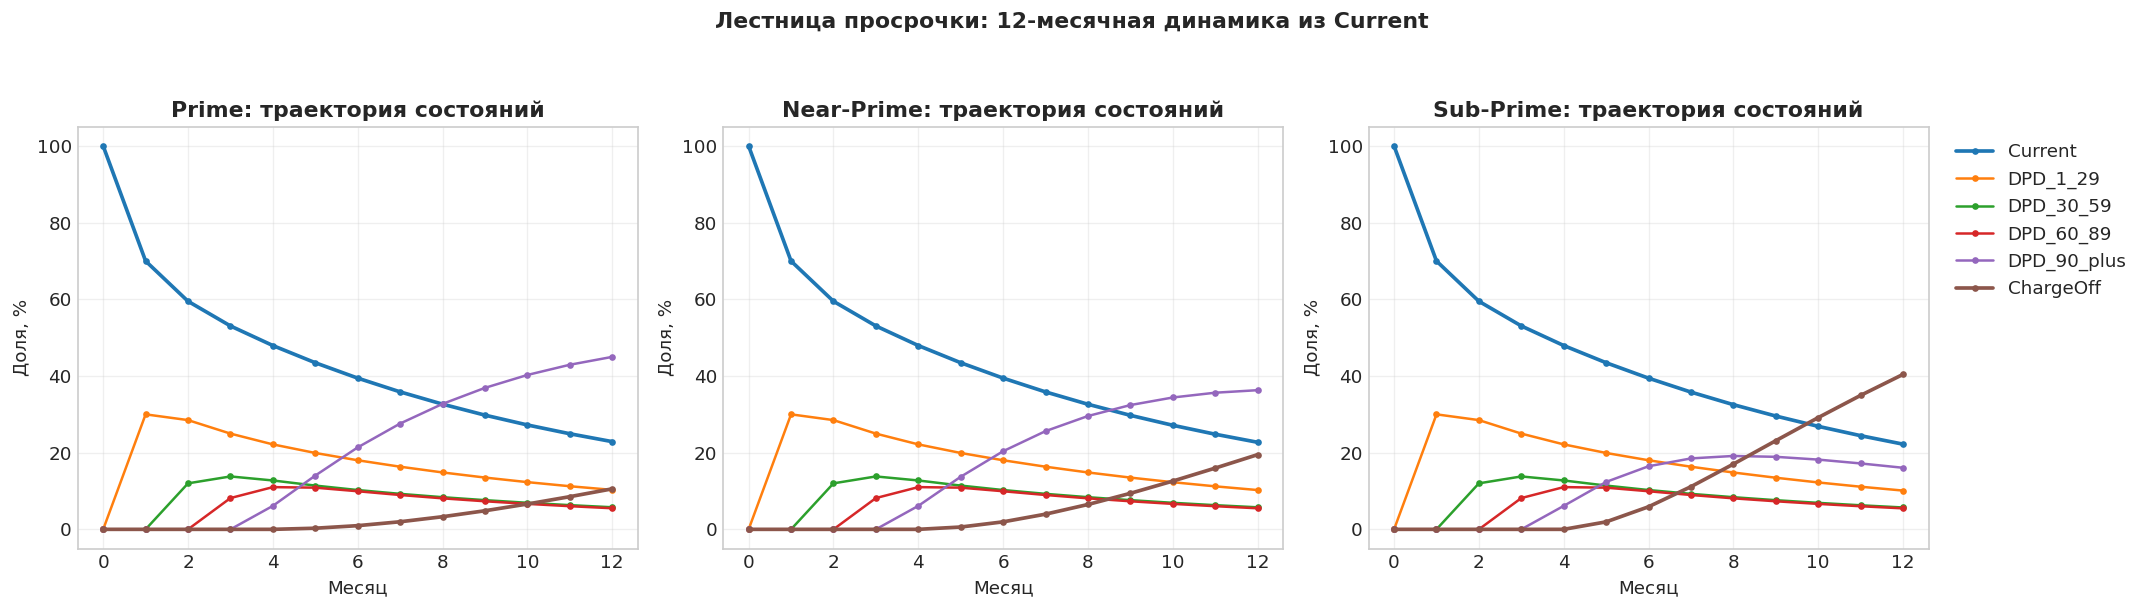

,tier,p_current_to_1_29,p_1_29_to_30_59,p_30_59_to_60_89,p_60_89_to_90_plus,p_90_plus_to_chargeoff,pd_annual_ladder
0,Prime,30.0,40.0,68.0,75.0,4.76,10.56
1,Near-Prime,30.0,40.0,68.0,75.0,9.85,19.49
2,Sub-Prime,30.0,40.0,68.0,75.0,31.86,40.43


In [2]:
import seaborn as sns

base_ladder = {tier: get_ladder_matrix('base', tier) for tier in ['Prime', 'Near-Prime', 'Sub-Prime']}

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for ax, tier in zip(axes, ['Prime', 'Near-Prime', 'Sub-Prime']):
    sns.heatmap(base_ladder[tier], annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=LADDER_STATES, yticklabels=LADDER_STATES,
                cbar=False, linewidths=0.4, ax=ax, vmin=0, vmax=1)
    pd12 = ladder_annual_pd(base_ladder[tier])
    ax.set_title(f'{tier}: PD_12={pd12:.1%}', fontweight='bold')
    ax.set_xlabel('Куда')
    ax.set_ylabel('Откуда')

plt.suptitle('Лестница просрочки: матрицы переходов (base)', y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

# Проекция при старте из Current
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for ax, tier in zip(axes, ['Prime', 'Near-Prime', 'Sub-Prime']):
    traj_l = project_ladder(base_ladder[tier], steps=12)
    for i, st in enumerate(LADDER_STATES):
        lw = 2.2 if st in ['Current', 'ChargeOff'] else 1.5
        ax.plot(range(13), traj_l[:, i] * 100, marker='o', ms=3, lw=lw, label=st)
    ax.set_title(f'{tier}: траектория состояний', fontweight='bold')
    ax.set_xlabel('Месяц')
    ax.set_ylabel('Доля, %')
    ax.grid(alpha=0.3)

axes[-1].legend(loc='upper left', bbox_to_anchor=(1.02, 1.0))
plt.suptitle('Лестница просрочки: 12-месячная динамика из Current', y=1.05, fontweight='bold')
plt.tight_layout()
plt.show()

rows_l = []
for tier in ['Prime', 'Near-Prime', 'Sub-Prime']:
    Tl = base_ladder[tier]
    rows_l.append({
        'tier': tier,
        'p_current_to_1_29': Tl[0, 1],
        'p_1_29_to_30_59': Tl[1, 2],
        'p_30_59_to_60_89': Tl[2, 3],
        'p_60_89_to_90_plus': Tl[3, 4],
        'p_90_plus_to_chargeoff': Tl[4, 5],
        'pd_annual_ladder': ladder_annual_pd(Tl),
    })

ladder_tbl = pd.DataFrame(rows_l)
for c in [x for x in ladder_tbl.columns if x != 'tier']:
    ladder_tbl[c] = ladder_tbl[c] * 100

display(ladder_tbl.round(2))

---
## 2. Годовая PD и проекция портфеля

Годовая PD считается как вероятность попасть в `Default` за 12 месяцев через матрицу переходов:

$$T_{12} = T^{12}, \quad PD_{annual}(s) = T_{12}[s, Default]$$

Откуда числа в выводе:
- `Prime`: $T_{12}[Prime, Default] = 10.6\%$
- `Near-Prime`: $T_{12}[Near\text{-}Prime, Default] = 19.5\%$
- `Sub-Prime`: $T_{12}[Sub\text{-}Prime, Default] = 40.4\%$

Важно: это не `12 × PD_monthly` и не всегда совпадает с $1-(1-PD_{monthly})^{12}$,
потому что в модели есть миграции между состояниями (апгрейд/даунгрейд).

Начальный портфель: **25% Prime, 50% Near-Prime, 25% Sub-Prime** (из EDA — Uniform `on_time_pct` на [80, 100]).

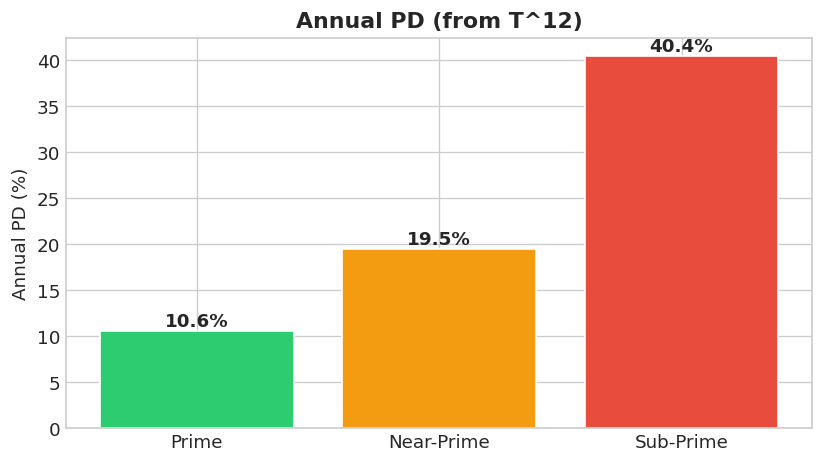

Годовая PD:
  Prime       : 10.6%
  Near-Prime  : 19.5%
  Sub-Prime   : 40.4%


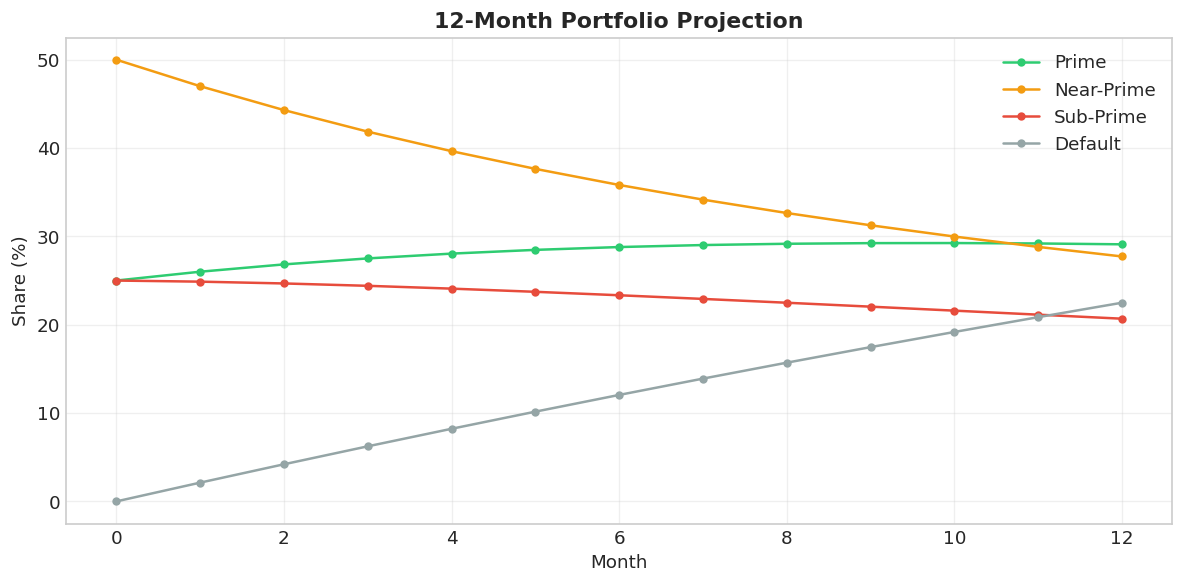


Стационарное распределение:
  Prime       : 0.0%
  Near-Prime  : 0.0%
  Sub-Prime   : 0.0%
  Default     : 100.0%

Портфель на 12-й месяц:
  Prime       : 29.1%
  Near-Prime  : 27.7%
  Sub-Prime   : 20.7%
  Default     : 22.5%


In [4]:
pds = plot_annual_pd(T)
print('Годовая PD:')
for s, p in zip(STATES[:3], pds):
    print(f'  {s:<12}: {p:.1%}')

pi0 = np.array([0.25, 0.50, 0.25, 0.00])
traj = project(T, pi0, steps=12)
plot_projection(traj)

pi_inf = stationary(T)
print('\nСтационарное распределение:')
for s, p in zip(STATES, pi_inf):
    print(f'  {s:<12}: {p:.1%}')

print(f'\nПортфель на 12-й месяц:')
for s, p in zip(STATES, traj[12]):
    print(f'  {s:<12}: {p:.1%}')

---
## 3. Риск-параметры клиентов

| Параметр | Значение | Обоснование |
|----------|----------|-------------|
| LGD | 55% | Бенчмарк необеспеченного потреб. кредитования |
| EAD | 50% от `initial_loan` за увеличение | Увеличение лимита пропорционально кредитной линии |
| Прибыль | $40 за увеличение | Спецификация задания |

$$EV_i = 40 \;-\; pd\_monthly_i \times 0.55 \times (initial\_loan_i \times 0.50)$$

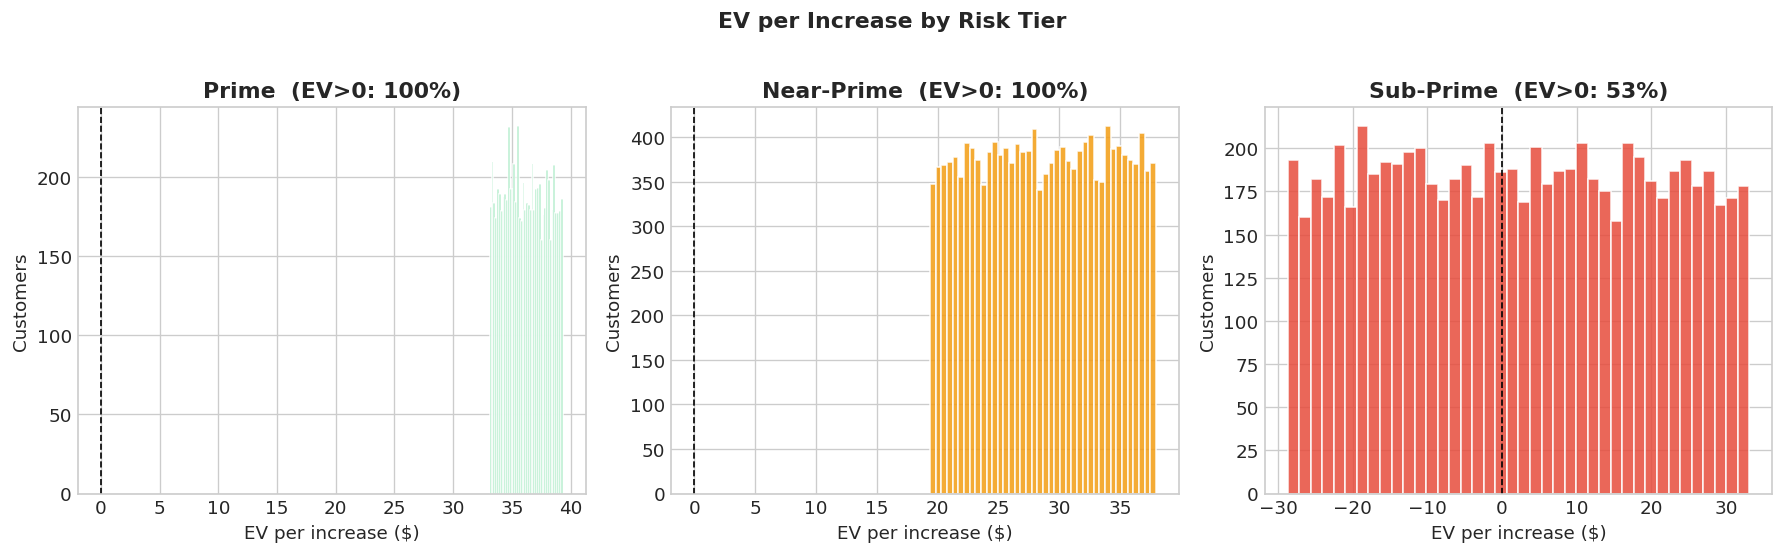

,n,avg_ev,pct_ev_pos,avg_el
risk_label,,,,
Prime,7520,36.191,1.000,3.809
Near-Prime,15103,28.701,1.000,11.299
Sub-Prime,7377,2.022,0.531,37.978



Клиентов с EV > 0: 26,537 / 30,000 (88.5%)


In [5]:
df = assign_params(df, T, lgd=0.55, ead_pct=0.50, profit=40)

plot_ev_distribution(df)

summary = (df.groupby('risk_label')
             .agg(n=('customer_id', 'count'),
                  avg_ev=('ev_per_increase', 'mean'),
                  pct_ev_pos=('ev_per_increase', lambda x: (x > 0).mean()),
                  avg_el=('el_per_increase', 'mean'))
             .reindex(['Prime', 'Near-Prime', 'Sub-Prime']))
display(summary.round(3))

n_pos = (df['ev_per_increase'] > 0).sum()
print(f'\nКлиентов с EV > 0: {n_pos:,} / {len(df):,} ({n_pos/len(df)*100:.1f}%)')

---
## 4. Анализ чувствительности

Сдвигаем месячную PD на ±2 п.п. от базовой. Наблюдаем влияние на годовую PD и EV за увеличение.

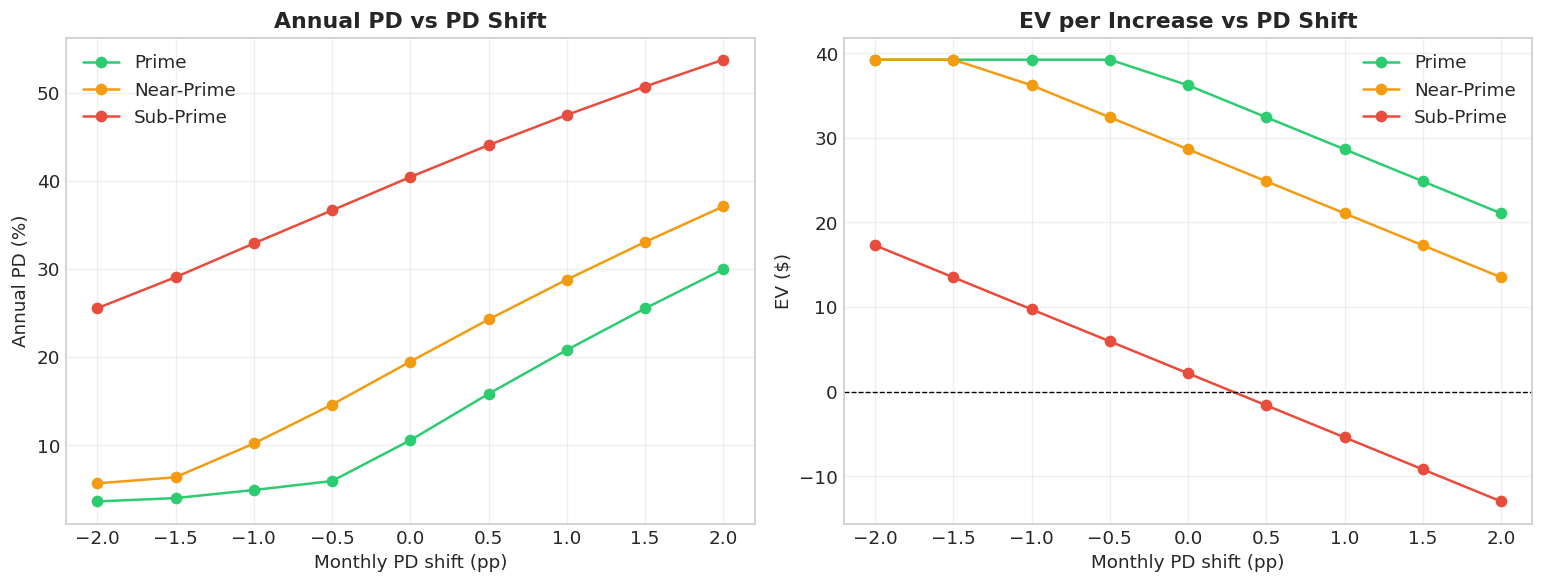

Prime: прибылен при всех протестированных сдвигах
Near-Prime: прибылен при всех протестированных сдвигах
Sub-Prime: убыточен при сдвиге >= +0.5 п.п.


In [6]:
sens = sensitivity(T, lgd=0.55, mean_ead=df['ead'].mean(), profit=40)
plot_sensitivity(sens)

for tier in STATES[:3]:
    s = sens[sens['tier'] == tier]
    neg = s[s['ev'] < 0]
    if len(neg):
        print(f'{tier}: убыточен при сдвиге >= {neg["shift_pp"].iloc[0]:+.1f} п.п.')
    else:
        print(f'{tier}: прибылен при всех протестированных сдвигах')

---
## 5. Ключевые выводы

1. **Марковская цепь** даёт месячную PD: Prime 0.5%, Near-Prime 1.5%, Sub-Prime 5.0%
2. **Годовая PD** (через $T^{12}$) значительно выше из-за путей деградации
3. **EV за увеличение** зависит от уровня риска И размера кредита — Sub-Prime с крупными кредитами убыточны
4. **Чувствительность**: результаты устойчивы к сдвигу ±1 п.п.; Sub-Prime становится полностью убыточным при ~+2 п.п.

`df_risk.csv` передаётся в ноутбуки 03 (Прогнозирование спроса) и 04 (Оптимизация).

In [7]:
out = ROOT / 'data' / 'df_risk.csv'
df.to_csv(out, index=False)
print(f'Сохранено: {out}')
print(f'Размер: {df.shape}')
print(f'Новые столбцы: pd_monthly, pd_annual, lgd, ead, el_per_increase, ev_per_increase')

Сохранено: /data/aturov/loan_limit_increases/data/df_risk.csv
Размер: (30000, 19)
Новые столбцы: pd_monthly, pd_annual, lgd, ead, el_per_increase, ev_per_increase
